In [2]:
%load_ext autoreload

In [3]:
%autoreload 2

## Feature Engineering & Preprocessing (One-Hot + Separate Scaling)

In [4]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# Add the scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import our feature engineering functions
from feature_engineering import *
from eda_functions import *
from gan_util import build_feature_info

## 1. Load raw data

In [5]:
df = load_data("../data/processed/gmsc_EDA_cleaned.csv", clean_cols=True, drop_unnamed=True)

# Preview
print("Raw data shape:", df.shape)
df.head()

Raw data shape: (150000, 11)


,Class,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Target mapping & missing values

In [6]:
df['Class'].unique()
df['Class'].value_counts()

Class
0    139974
1     10026
Name: count, dtype: int64

In [7]:
missing = handle_missing_values(df)

===== MISSING VALUES REPORT =====
Column                                      Missing     Percent
-----------------------------------------------------------------
MonthlyIncome                                29,731       19.8%
NumberOfDependents                            3,924        2.6%
-----------------------------------------------------------------
Total                                        33,655


In [8]:
if 'MonthlyIncome' in missing.index:
    median_income = df['MonthlyIncome'].median()
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)  # ← no inplace
    print(f"  MonthlyIncome: {missing['MonthlyIncome']:,} missing → median ({median_income:,.0f})")

  MonthlyIncome: 29,731 missing → median (5,400)


In [9]:

# NumberOfDependents → mode (discrete count, most common = 0)
if 'NumberOfDependents' in missing.index:
    mode_dependents = df['NumberOfDependents'].mode()[0]
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)  # ← no inplace
    print(f"  NumberOfDependents: {missing['NumberOfDependents']:,} missing → mode ({int(mode_dependents)})")


print("✅ All missing values handled.")
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

  NumberOfDependents: 3,924 missing → mode (0)
✅ All missing values handled.

Remaining missing values: 0


## 4. Identify numerical / categorical columns

In [10]:
num_cols, cat_cols = get_feature_types(df, target='Class')
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Categorical: []


## 5. Auto‑detect low‑cardinality numerical columns as categorical

In [11]:
## Automatically detect low‑cardinality numerical columns as categorical
num_cols, cat_cols = auto_detect_categorical(df, num_cols, cat_cols, unique_threshold=20)
print("\nAfter auto‑detection:")
print("Numerical (continuous):", num_cols)
print("Categorical (including detected):", cat_cols)

Moving 'NumberOfTime30-59DaysPastDueNotWorse' to categorical (unique values: 16 ≤ 20)
Moving 'NumberOfTimes90DaysLate' to categorical (unique values: 19 ≤ 20)
Moving 'NumberOfTime60-89DaysPastDueNotWorse' to categorical (unique values: 13 ≤ 20)
Moving 'NumberOfDependents' to categorical (unique values: 13 ≤ 20)

After auto‑detection:
Numerical (continuous): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Categorical (including detected): ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   Class                                 150000 non-null  int64   
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64 
 2   age                                   150000 non-null  int64   
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  category
 4   DebtRatio                             150000 non-null  float64 
 5   MonthlyIncome                         150000 non-null  float64 
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64   
 7   NumberOfTimes90DaysLate               150000 non-null  category
 8   NumberRealEstateLoansOrLines          150000 non-null  int64   
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  category
 10  NumberOfDependents                    150000 non-null  c

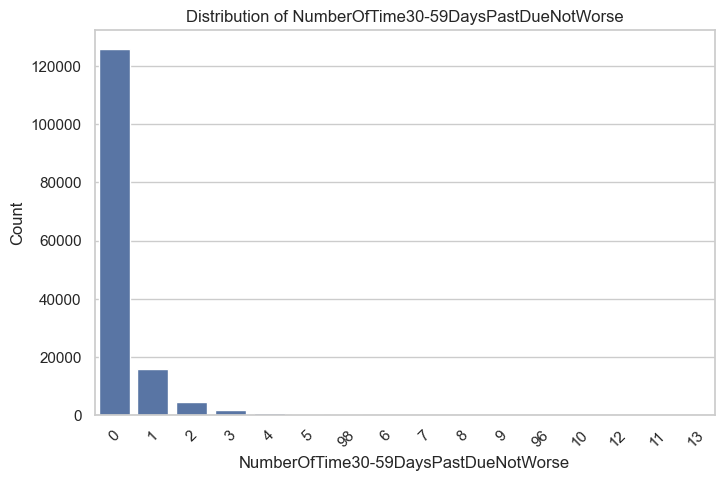

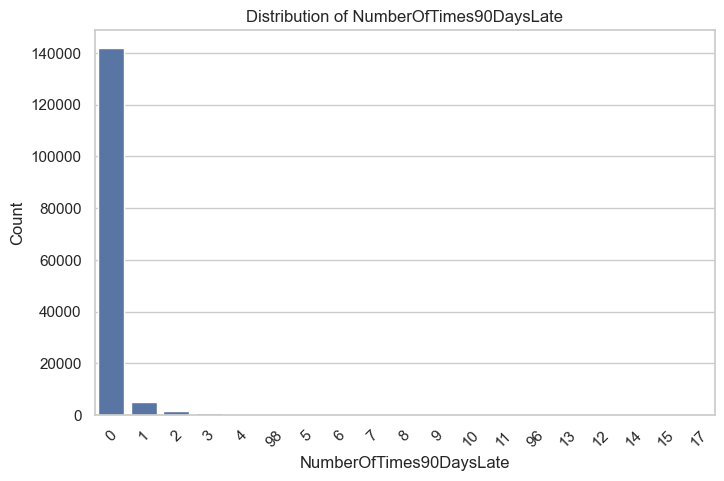

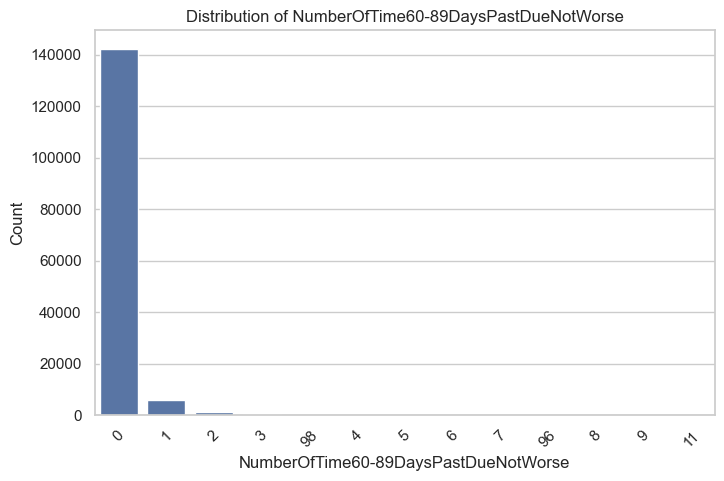

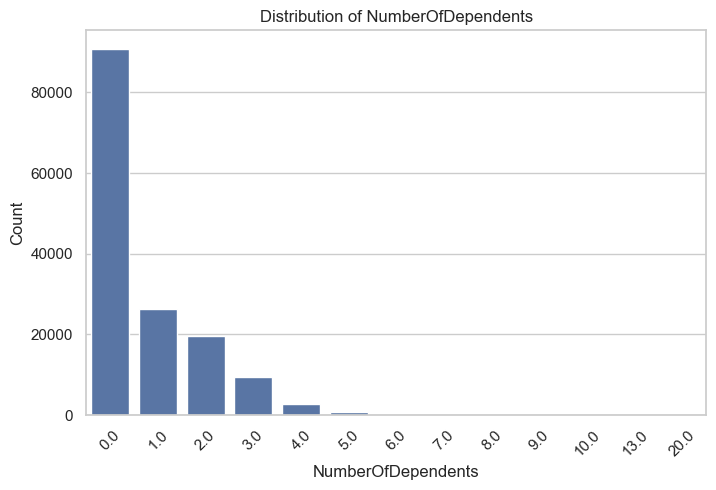

In [13]:
# Count plots (horizontal, top 10 categories if needed)
plot_categorical(df, cols=cat_cols, max_categories=25, horizontal=False)

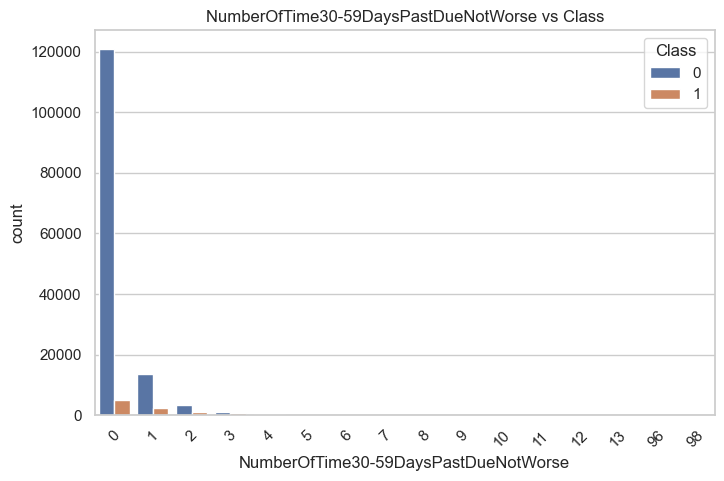

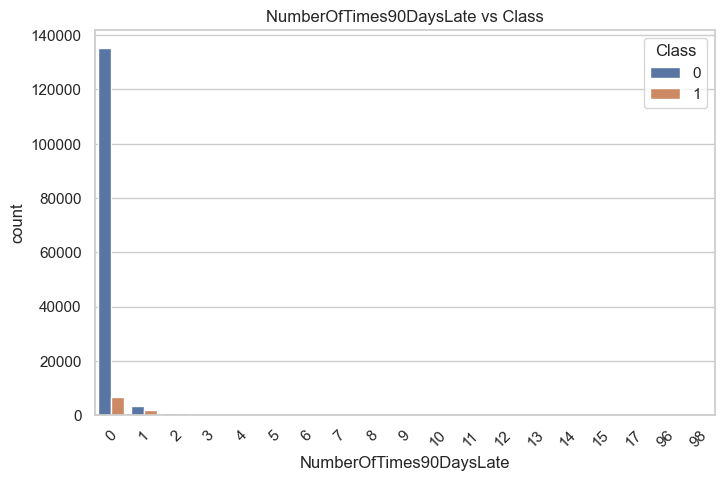

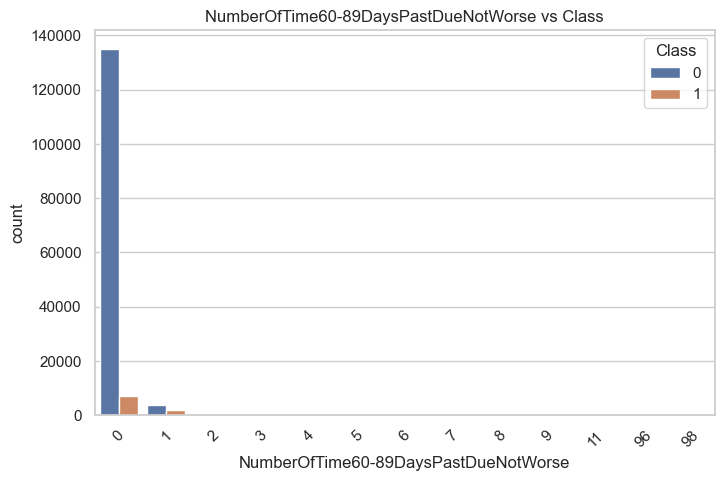

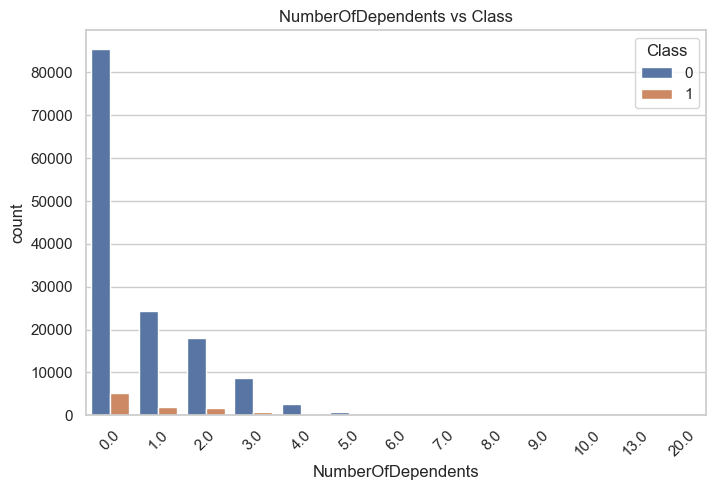

In [14]:
# Categorical vs target
plot_cat_vs_target(df, cat_cols, target='Class')

In [15]:

# %% [markdown]
# ## 12. Outlier Detection (IQR Method)

# %%
print("===== OUTLIER SUMMARY (IQR) =====")
outlier_summary(df, cols=num_cols)


===== OUTLIER SUMMARY (IQR) =====
RevolvingUtilizationOfUnsecuredLines: 763 outliers
age: 46 outliers
DebtRatio: 31311 outliers
MonthlyIncome: 9149 outliers
NumberOfOpenCreditLinesAndLoans: 3980 outliers
NumberRealEstateLoansOrLines: 793 outliers


In [19]:
# %% [markdown]
# ## Outlier Handling (Clipping + Category Cleaning)

# %%


print("===== OUTLIER HANDLING =====")
df_original_shape = df.shape
print(f"Dataset shape before handling: {df_original_shape}")

# Ensure proper numeric types
for col in ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clip numerical features
clipping = {
    'RevolvingUtilizationOfUnsecuredLines': 0.99,
    'DebtRatio': 0.90,
    'MonthlyIncome': 0.90,
    'NumberOfOpenCreditLinesAndLoans': 0.95,
    'NumberRealEstateLoansOrLines': 0.99,
}
for col, q in clipping.items():
    upper = df[col].quantile(q)
    n = (df[col] > upper).sum()
    df[col] = df[col].clip(upper=upper)
    print(f"  {col}: {n:,} clipped at {q*100:.0f}th percentile ({upper:.2f})")

# Clip age
df['age'] = df['age'].clip(lower=21, upper=100)
print(f"  age: {(df_original_shape[0] - (df['age'].between(21,100)).sum())} clipped to 21–100")

# Remove rare categories
category_rules = {
    'NumberOfTime30-59DaysPastDueNotWorse': [0,1,2,3,4,5,6,98],
    'NumberOfTimes90DaysLate': [0,1,2,3,4,5,98],
    'NumberOfTime60-89DaysPastDueNotWorse': [0,1,2,3,98],
    'NumberOfDependents': [0,1,2,3,4,5],
}
for col, valid in category_rules.items():
    df = df[df[col].isin(valid)]
    print(f"  {col}: kept categories {valid}")

# Clean zero-count categories
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 
            'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']:
    df[col] = df[col].astype(int).astype('category')

# Summary
df = df.reset_index(drop=True)
print(f"\nRows removed: {df_original_shape[0] - df.shape[0]:,} "
      f"({(df.shape[0]/df_original_shape[0]*100):.1f}% retained)")
print("✅ Outlier handling complete.")

# %% [markdown]
# ## Verify Outlier Handling

# %%
# Outlier summary
key_features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
outlier_summary(df, cols=key_features)

# Value counts for categorical columns
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 
            'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']:
    print(f"\n{col}:\n{df[col].value_counts().sort_index()}")

# Value ranges
print("\n===== VALUE RANGES =====")
for col in key_features:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

===== OUTLIER HANDLING =====
Dataset shape before handling: (149318, 11)
  RevolvingUtilizationOfUnsecuredLines: 1,494 clipped at 99th percentile (1.09)
  DebtRatio: 14,925 clipped at 90th percentile (1269.00)
  MonthlyIncome: 14,931 clipped at 90th percentile (10749.00)
  NumberOfOpenCreditLinesAndLoans: 0 clipped at 95th percentile (18.00)
  NumberRealEstateLoansOrLines: 0 clipped at 99th percentile (4.00)
  age: 0 clipped to 21–100
  NumberOfTime30-59DaysPastDueNotWorse: kept categories [0, 1, 2, 3, 4, 5, 6, 98]
  NumberOfTimes90DaysLate: kept categories [0, 1, 2, 3, 4, 5, 98]
  NumberOfTime60-89DaysPastDueNotWorse: kept categories [0, 1, 2, 3, 98]
  NumberOfDependents: kept categories [0, 1, 2, 3, 4, 5]

Rows removed: 0 (100.0% retained)
✅ Outlier handling complete.
RevolvingUtilizationOfUnsecuredLines: 0 outliers
age: 45 outliers
DebtRatio: 31201 outliers
MonthlyIncome: 0 outliers
NumberOfOpenCreditLinesAndLoans: 0 outliers
NumberRealEstateLoansOrLines: 0 outliers

NumberOfTime30-

In [20]:
print("Numerical (continuous):", num_cols)
print("Categorical (including detected):", cat_cols)

Numerical (continuous): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Categorical (including detected): ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 5. One-hot encode categorical variables

In [21]:
df_encoded, cat_cols = encode_categorical(df)   # works because columns are already 'category'
print("Shape after one‑hot:", df_encoded.shape)


# Verify that InstallmentRate was one‑hot expanded
print([c for c in df_encoded.columns if 'InstallmentRate' in c])
df_encoded.head()


Shape after one‑hot: (149318, 33)
[]


,Class,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse_0,NumberOfTime30-59DaysPastDueNotWorse_1,NumberOfTime30-59DaysPastDueNotWorse_2,...,NumberOfTime60-89DaysPastDueNotWorse_1,NumberOfTime60-89DaysPastDueNotWorse_2,NumberOfTime60-89DaysPastDueNotWorse_3,NumberOfTime60-89DaysPastDueNotWorse_98,NumberOfDependents_0,NumberOfDependents_1,NumberOfDependents_2,NumberOfDependents_3,NumberOfDependents_4,NumberOfDependents_5
0,1,0.766127,45,0.802982,9120.0,13,4,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,0,0.957151,40,0.121876,2600.0,4,0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,0,0.658180,38,0.085113,3042.0,2,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,0,0.233810,30,0.036050,3300.0,5,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0.907239,49,0.024926,10749.0,7,1,False,True,False,...,False,False,False,False,True,False,False,False,False,False


## 6. Build feature_info for GAN

In [22]:
feature_info = build_feature_info(df_encoded, cat_cols, target_col='Class')
column_order = df_encoded.drop(columns=['Class']).columns.tolist()

print("Numerical features:", feature_info["numerical"])
print("Categorical groups:", list(feature_info["categorical"].keys()))

Numerical features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Categorical groups: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 7. Save everything

In [23]:
df_encoded.to_csv("../data/processed/gmsc_processed_onehot.csv", index=False)
joblib.dump(feature_info, "../models/feature_info_gmsc.pkl")
joblib.dump(column_order, "../models/column_order_gmsc.pkl")
joblib.dump(cat_cols, "../models/cat_cols_gmsc.pkl")
print("All saved.")

All saved.
